In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [3]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [4]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


✍️ 위에서 채운 encode / reparameterize 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.

encode는 입력 데이터 x를 잠재공간의 확률 분포로 변환하는 역할을 한다. fc1과 ReLU를 거쳐 특징 h1을 만든뒤, fc21(h1)을 통해 평균 mu, fc22(h1)을 통해 로그분산 logvar를 계산한다. 즉, 하나의 고정된 잠재벡터를 만드는 것이 아니라 잠재변수 z가 따를 분포의 파라미터를 구한다.

reparameterize는 이 분포에서 실제 잠재벡터 z를 샘플링한다. logvar로부터 표준편차 std를 구하고, 표준정규분포에서 eps를 생성한 뒤 mu+eps*std로 z를 계산한다. 이렇게 하면 무작위 샘플링을 포함하면서도 역전파가 가능해져 VAE를 학습할 수 있다.

In [5]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

elbo_loss는 VAE의 학습 손실을 계산하는 함수이다. BCE는 원본과 복원 이미지의 차이를 계산하는 복원 손실, KLD는 잠재분포가 표준정규분포에 가까워지도록 만드는 정규화 손실이다. 따라서 BCE + KLD를 합쳐 전체 손실로 사용한다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.

KL Divergence는 encoder가 만든 잠재분포가 표준정규분포에 가깝도록 만들어서 잠재공간을 규칙적으로 정리해준다. 따라서 새로운 z를 샘플링해도 의미 있는 데이터를 생성할 수 있고, VAE가 단순 복원 모델이 아니라 생성 모델로 동작할 수 있도록 해주기 위해 포함된다.


In [6]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3183 | Val Loss: 1.0355
Epoch [2/15] Train Loss: 0.9659 | Val Loss: 0.9362
Epoch [3/15] Train Loss: 0.9055 | Val Loss: 0.8973
Epoch [4/15] Train Loss: 0.8803 | Val Loss: 0.8795
Epoch [5/15] Train Loss: 0.8653 | Val Loss: 0.8686
Epoch [6/15] Train Loss: 0.8550 | Val Loss: 0.8596
Epoch [7/15] Train Loss: 0.8474 | Val Loss: 0.8550
Epoch [8/15] Train Loss: 0.8422 | Val Loss: 0.8506
Epoch [9/15] Train Loss: 0.8372 | Val Loss: 0.8445
Epoch [10/15] Train Loss: 0.8337 | Val Loss: 0.8417
Epoch [11/15] Train Loss: 0.8308 | Val Loss: 0.8411
Epoch [12/15] Train Loss: 0.8278 | Val Loss: 0.8375
Epoch [13/15] Train Loss: 0.8256 | Val Loss: 0.8362
Epoch [14/15] Train Loss: 0.8238 | Val Loss: 0.8342
Epoch [15/15] Train Loss: 0.8219 | Val Loss: 0.8327


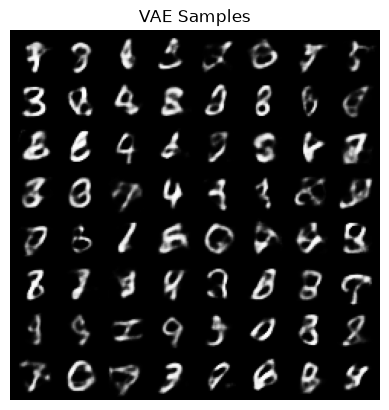

In [7]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [9]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [10]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

Generator.forward는 잠재벡터 z를 입력받아 이미지를 생성하는 과정이다. ConvTranspose2d를 여러번 거치면서 공간의 크기를 키우고, 각 중간 단계에서 BatchNorm과 ReLU를 적용한다. 마지막에는 tconv4를 통과한 뒤 tanh를 적용해 최종 이미지 값을 생성한다.


In [11]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

Discriminator.forward는 입력 이미지가 실제 이미지인지 생성된 가짜 이미지인지 판별하는 과정이다. Conv2d로 이미지 특징을 추출하면서 크기를 줄이고, 중간층에는 BatchNorm과 LeakyReLU를 적용한다. 마지막엔 sigmoid를 사용해 실제일 확률을 0에서 1 사이 값으로 출력한다.


In [12]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [13]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.8097 | Loss G: 1.6776
Epoch [2/15] Loss D: 0.9057 | Loss G: 1.4412
Epoch [3/15] Loss D: 1.0032 | Loss G: 1.3093
Epoch [4/15] Loss D: 1.0268 | Loss G: 1.3082
Epoch [5/15] Loss D: 1.0177 | Loss G: 1.3222
Epoch [6/15] Loss D: 1.0110 | Loss G: 1.3508
Epoch [7/15] Loss D: 0.9947 | Loss G: 1.3897
Epoch [8/15] Loss D: 0.9996 | Loss G: 1.3815
Epoch [9/15] Loss D: 0.9845 | Loss G: 1.4103
Epoch [10/15] Loss D: 0.9830 | Loss G: 1.4323
Epoch [11/15] Loss D: 0.9649 | Loss G: 1.4589
Epoch [12/15] Loss D: 0.9521 | Loss G: 1.4873
Epoch [13/15] Loss D: 0.9490 | Loss G: 1.4985
Epoch [14/15] Loss D: 0.9177 | Loss G: 1.5425
Epoch [15/15] Loss D: 0.9165 | Loss G: 1.5752


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

GAN에서 generator와 discriminator를 번갈아 학습하는 과정이다. Discriminator는 실제 이미지는 real, 생성이미지는 fake로 구분하도록 학습하고, Generator는 자신이 만든 이미지를 Discriminator가 real로 판단하도록 학습한다. 각 손실을 계산한 뒤 backward()와 step()을 통해 두 모델의 가중치를 각각 업데이트한다.

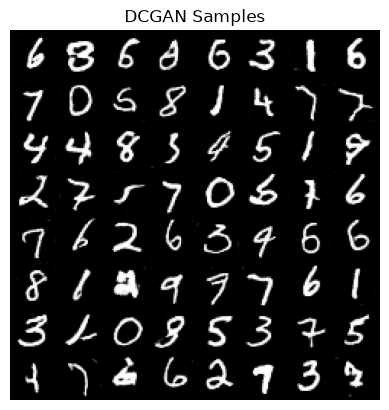

In [14]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

VAE는 입력 이미지를 잠재분포로 압축한 후에 복원하는 방식으로 학습하며, 손실함수에 재구성 손실과 KL Divergence를 함께 사용한다. 이 과정을 통해 픽셀 단위의 복원을 잘하도록 학습되기 때문에 경계가 부드럽고 흐릿한 이미지가 생성되는 경향이 있다. 반면 DCGAN은 Generator와 Discriminator가 서로 경쟁하면서 학습한다. Generator는 Discriminator를 속일 만큼 실제와 비슷한 이미지를 만들도록 학습되기 때문에 숫자의 윤곽이나 세부 특징을 더 선명하게 표현하는 경향이 있다. 따라서 일반적으로 VAE보다 DCGAN의 생성 이미지가 더 또렷하게 보인다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

Discriminator가 너무 빨리 강해지면 가짜이미지를 거의 완벽하게 구분하게 되어 Generator가 받을 gradient가 매우 작아지는 Vanishing gradient 문제가 발생할 수 있다. 그러면 Generator 학습이 거의 진행되지 않는다. 반대로 Generator가 특정 패턴만 반복해서 Discriminator를 잘 속이게 되면 다양한 이미지를 만들지 못하고 비슷한 결과만 생성하는 Mode collapse가 발생할 수 있다. 따라서 GAN은 두 모델의 학습 균형이 중요하다.


In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


In [17]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

forward_diffusion은 원본 이미지 x0에 timestep t에 맞는 양의 가우시안 노이즈를 추가해 x_t를 만드는 함수이다. sqrt_ac는 원본 이미지의 비중, sqrt_omac는 노이즈의 비중을 각각 정하고 둘을 더해서 noisy image를 생성한다. 이후 학습에 사용하도록 x_t와 실제로 추가했던 noise를 함께 반환해준다.


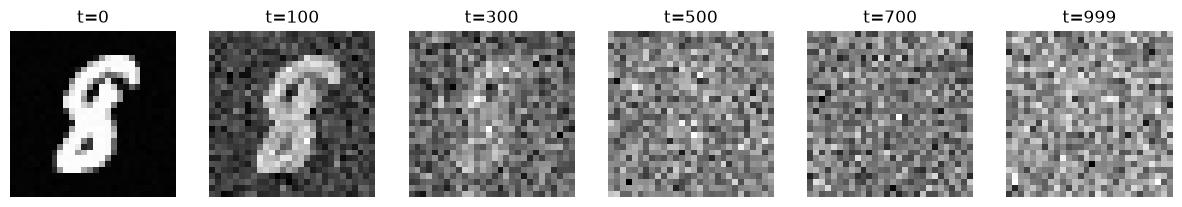

In [18]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


In [19]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

timestep 결합 코드는 현재 diffusion 단계의 시간 정보를 UNet의 특징맵에 반영하는 역할을 한다. t를 임베딩한 후 time_proj로 256차원에 맞추고 (B, 256, 1 ) 형태로 바꾼 후, h3에 더해 현재 timestep 정보를 bottleneck에 전달한다.


In [20]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

ddpm_loss는 DDPM이 이미지에 추가된 노이즈를 얼마나 잘 예측하는지를 계산하는 손실함수이다. 임의의 timestep t를 뽑고 forward_diffusion으로 x_t와 실제 노이즈를 만든다. 이후 모델이 예측한 predicted_noise와 실제 noise의 차이를 MSE로 계산해 학습에 사용한다.


In [21]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


c:\Users\harmo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\harmo\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\harmo\.cache\huggingface\hub\models--nathanReitinger--MNIST-diffusion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Pytho

FrozenDict([('num_train_timesteps', 1000), ('beta_start', 0.0001), ('beta_end', 0.02), ('beta_schedule', 'squaredcos_cap_v2'), ('trained_betas', None), ('variance_type', 'fixed_small'), ('clip_sample', True), ('prediction_type', 'epsilon'), ('thresholding', False), ('dynamic_thresholding_ratio', 0.995), ('clip_sample_range', 1.0), ('sample_max_value', 1.0), ('timestep_spacing', 'leading'), ('steps_offset', 0), ('rescale_betas_zero_snr', False), ('_class_name', 'DDPMScheduler'), ('_diffusers_version', '0.27.2')])


100%|██████████| 200/200 [00:11<00:00, 16.69it/s]


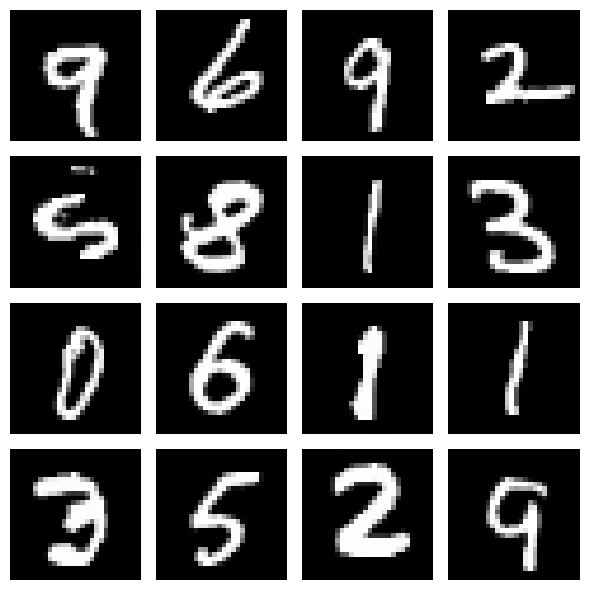

In [22]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

DDPM은 랜덤 노이즈에서 시작해 여러 단계의 denoising을 거쳐 이미지를 생성하므로, 초기 노이즈와 각 단계의 예측 오차에 따라 결과가 달라질 수 있다. 또한 숫자 label을 조건으로 주지 않는 모델이기 때문에 다양한 MNIST 필체를 생성하며, 일부 결과는 선명하지만 일부는 악필처럼 불완전하게 나타날 수 있다.

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...

이론적으로 VAE는 학습이 안정적이고 추론이 빠르지만 생성 결과가 다소 흐릿할 수 있다. GAN은 선명한 이미지를 빠르게 생성할 수 있지만 Generator와 Discriminator의 경쟁 학습으로 인해 학습이 불안정하고 Mode Collapse 등이 발생할 수 있다. Diffusion은 노이즈 예측 방식으로 학습이 비교적 안정적이며 높은 품질과 다양성을 보이지만, 반복적인 denoising 과정 때문에 추론 속도가 가장 느리다.

In [24]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cpu")


Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  2.05it/s]
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please ma

100%|██████████| 50/50 [04:37<00:00,  5.54s/it]


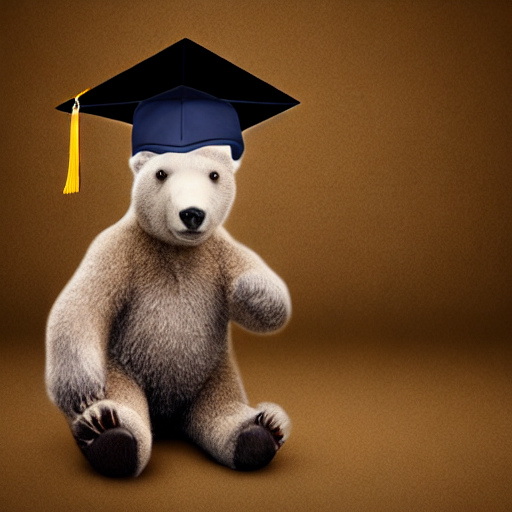

In [25]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=50,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

num_inference_steps는 Diffusion 모델이 노이즈를 몇 단계에 걸쳐 제거하며 이미지를 생성할지 정하는 값이다. 값이 크면 더 많은 denoising 과정을 거쳐 품질이 좋아질 수 있지만 생성 시간이 길어지고, 값이 작으면 생성은 빨라지지만 이미지 품질이 떨어지거나 세부 표현이 부족할 수 있다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

guidance_scale이 낮으면 프롬프트에 대한 제약이 약해져 보다 자유로운 이미지가 생성되지만, 프롬프트의 내용이 충분히 반영되지 않을 수 있다. 반대로 값이 높으면 프롬프트의 특징을 더 강하게 반영하지만, 지나치게 높은 경우 이미지가 부자연스럽거나 세부 표현이 과도하게 강조될 수 있다. 따라서 적절한 CFG 값을 설정해 프롬프트 일치도와 이미지 자연스러움 사이의 균형을 맞추는 것이 중요하다.


100%|██████████| 30/30 [02:55<00:00,  5.86s/it]


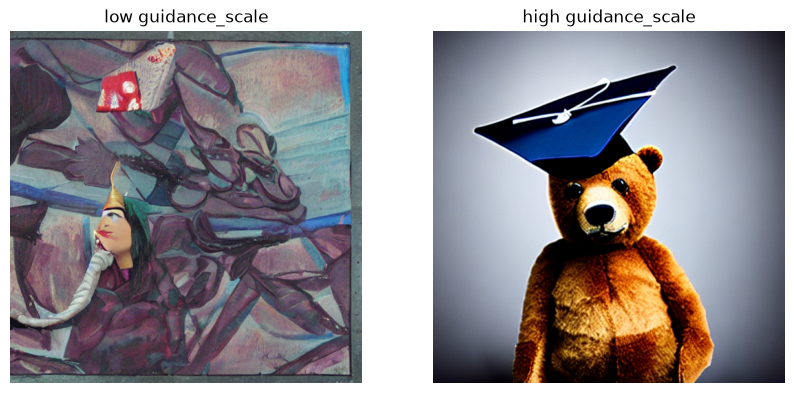

In [27]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

guidance_scale 비교 코드는 같은 프롬프트에서 CFG 값을 낮게 설정한 경우와 높게 설정한 경우의 생성 이미지를 비교하는 코드이다. guidance_scale=1과 15로 각각 이미지를 생성한 뒤, 두 결과를 나란히 시각화해 프롬프트 반영 정도와 이미지 자연스러움의 차이를 확인할 수 있다.


In [ ]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

DDPM의 reverse process는 현재 상태에서 바로 이전 단계로 이동하면서 예측한 노이즈를 제거하는 과정을 여러번 반복한다. 즉, 작은 timestep을 하나씩 거치는 확률적 샘플링 과정이라 많은 step이 필요하다. 반면 DDIM은 모델이 예측한 노이즈를 이용해서 원본 이미지의 방향을 추정하고, 중간 timestep 일부를 건너뛰면서 더 큰 간격으로 denoising 할 수 있다. 또한 DDPM보다 샘플링 과정의 무작위성을 줄일 수 있어 적은 step에서도 비교적 일관된 경로로 이미지를 복원할 수 있다. 따라서 같은 학습된 diffusion 모델을 사용하더라도 DDIM은 훨씬 적은 inference step으로 그럴듯한 이미지를 빠르게 생성할 수 있다.


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)

별도의 모델 학습이나 복잡한 환경 설정 없이 웹에서 바로 실행할 수 있다는 점이 편리했다. 특히 같은 Hugging Face 플랫폼에서도 모델마다 입력 방식과 출력 형태가 매우 다양하다는 점을 확인하였다. 실제 서비스를 직접 체험하면서 pretrained model을 쉽게 활용할 수 있다는 Hugging Face의 장점을 이해할 수 있었다.


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답) 검토 및 문법 디버깅

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: 없음

- **실제 대화 내역** 붙여넣기:

```
오류 원인은 딱 이거야.

AssertionError: Torch not compiled with CUDA enabled

현재 설치된 PyTorch가 CUDA를 지원하지 않는 CPU 버전인데, 코드에서 강제로

pipe = pipe.to("cuda")

를 실행해서 에러가 난 거야.

일단 실행하려면

코드를 이렇게 바꿔.

import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "..."

dtype = torch.float16 if device == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)

pipe = pipe.to(device)

print("사용 device:", device)

즉 기존의

torch_dtype=torch.float16
pipe = pipe.to("cuda")

를 무조건 쓰면 안 돼.

현재 네 환경에서는 아마

print(torch.cuda.is_available())

결과가

False

일 거야.

그런데 NVIDIA GPU가 있는 컴퓨터라면

GPU가 있는데도 False라면 CPU 전용 PyTorch를 설치한 상태일 가능성이 높아.

PowerShell에서 먼저:

nvidia-smi

를 쳐봐.

NVIDIA GPU 정보가 나오면 GPU는 있는 거고, 다음도 확인해:

python -c "import torch; print(torch.__version__); print(torch.version.cuda); print(torch.cuda.is_available())"

만약 이런 식이면:

torch.version.cuda = None
torch.cuda.is_available() = False

PyTorch를 CUDA 버전으로 다시 설치해야 한다.

반대로 nvidia-smi 자체가 안 되고 NVIDIA GPU가 없는 PC라면 CPU로 실행해야 하는데, Stable Diffusion은 CPU에서는 상당히 느릴 수 있다.

지금 핵심은 Stable Diffusion 코드 문제가 아니라 네 PyTorch가 CUDA 없는 버전이라는 것이야. nvidia-smi 결과 보내주면 CUDA 버전으로 다시 설치해야 하는 상황인지 바로 봐줄게.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? 파라미터 조정 및 이미지를 보고 어떤것이 더 흐리고 명확한지 판단하기.
